In [1]:
using Pkg
Pkg.add("DifferentialEquations")
Pkg.add("Plots")


   Resolving package versions...
  No Changes to `/opt/julia/environments/v1.9/Project.toml`
  No Changes to `/opt/julia/environments/v1.9/Manifest.toml`
   Resolving package versions...
  No Changes to `/opt/julia/environments/v1.9/Project.toml`
  No Changes to `/opt/julia/environments/v1.9/Manifest.toml`


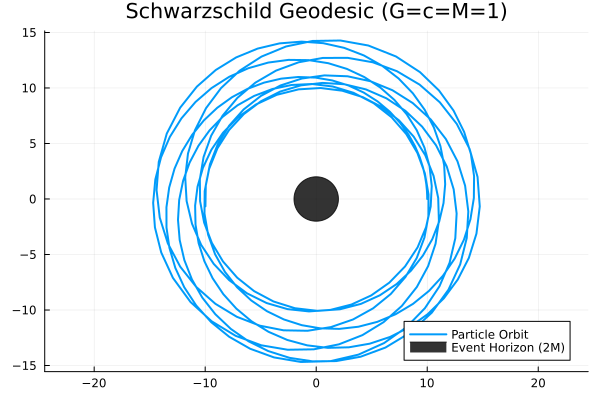

In [2]:
using DifferentialEquations
using Plots

# --- 1. 物理パラメータと方程式の定義 ---

# 物理定数 (幾何学単位系 G=c=M=1 を使用)
const M = 1.0 

# シュワルツシルト時空の測地線方程式
# u = [t, r, ϕ, dt/dτ, dr/dτ, dϕ/dτ]
# τ (tau) は固有時
function schwarzschild_geodesic!(du, u, p, tau)
    # 変数の展開
    t, r, phi, dt, dr, dphi = u
    
    # 共通項の計算 (計算コスト削減のため)
    # シュワルツシルト半径 rs = 2M
    term1 = 1.0 - 2.0*M/r
    
    # クリストッフェル記号に関連する項
    # これらはアインシュタイン方程式から導かれる接続係数です
    
    # dt/dτ の時間発展 (tの2階微分に対応)
    # d²t/dτ² + 2/r(r-2M) * dt/dτ * dr/dτ = 0
    du[1] = dt
    du[4] = -(2.0*M / (r^2 * term1)) * dr * dt

    # dr/dτ の時間発展 (rの2階微分に対応)
    # d²r/dτ² + ... (遠心力項や重力項)
    du[2] = dr
    du[5] = -(M * term1 / r^2) * dt^2 + 
            (M / (r^2 * term1)) * dr^2 + 
            (r * term1) * dphi^2

    # dϕ/dτ の時間発展 (ϕの2階微分に対応)
    # d²ϕ/dτ² + 2/r * dr/dτ * dϕ/dτ = 0 (角運動量保存に対応)
    du[3] = dphi
    du[6] = -(2.0 / r) * dr * dphi
end

# --- 2. 初期条件の設定 ---

# スタート地点: r = 10M, ϕ = 0
r0 = 10.0
phi0 = 0.0
t0 = 0.0

# 初速度の設定
# 安定した周回軌道になるように適当なパラメータを設定します
# ※ 本来は g_μν u^μ u^ν = -1 (質量あり) を満たすよう厳密に正規化する必要がありますが、
#    ここでは定性的な軌道を見るために簡略化して設定します。
L = 4.0 # 角運動量パラメータ
E = sqrt((1 - 2M/r0) * (1 + L^2/r0^2)) # エネルギー（円軌道の条件に近い値）

# 固有時の初期微分値 (速度ベクトル)
dt0 = E / (1 - 2M/r0)
dphi0 = L / r0^2
dr0 = 0.0 # 半径方向の初速度はゼロ（近日点/遠日点から開始）

# 状態ベクトル u0 = [t, r, ϕ, dt, dr, dphi]
u0 = [t0, r0, phi0, dt0, dr0, dphi0]

# --- 3. ソルバーの実行 ---

# 固有時 τ の範囲 (0 から 2000 までシミュレーション)
tspan = (0.0, 2000.0)

# 問題の定義
prob = ODEProblem(schwarzschild_geodesic!, u0, tspan)

# 求解 (Tsit5: Tsitourasの5(4)次ルンゲ・クッタ法。非剛性方程式に非常に高速)
sol = solve(prob, Tsit5(), reltol=1e-8, abstol=1e-8)

# --- 4. 結果の可視化 ---

# 極座標 (r, ϕ) を 直交座標 (x, y) に変換
r_sol = sol[2, :]
phi_sol = sol[3, :]

x = r_sol .* cos.(phi_sol)
y = r_sol .* sin.(phi_sol)

# プロット作成
plot(x, y, label="Particle Orbit", aspect_ratio=:equal, lw=2, title="Schwarzschild Geodesic (G=c=M=1)")

# ブラックホール（事象の地平面）を描画 (半径 2M)
theta_bh = range(0, 2pi, length=100)
plot!(2M .* cos.(theta_bh), 2M .* sin.(theta_bh), fill=true, color=:black, label="Event Horizon (2M)", alpha=0.8)

# 表示
display(current())
